# FMA Baseline — MFCC → 2D CNN (Music Genre Recognition)

Reproduces the MFCC-based 2D CNN baseline from the official FMA repository:
- **Reference:** `FMA/fma-repo/baselines.ipynb` §3.1 "ConvNet on MFCC"
- **Paper:** Li et al., "Automatic Musical Pattern Feature Extraction Using Convolutional Neural Network", IMECS 2010

**Architecture (faithful to the original):**

| Layer | Output shape |
|---|---|
| Input | `(13, 2582, 1)` — 13 MFCC × 2582 time frames |
| Conv2D(3, 13×10, stride 1×4) + ReLU | `(1, 644, 3)` |
| Conv2D(15, 1×10, stride 1×4) + ReLU | `(1, 159, 15)` |
| Conv2D(65, 1×10, stride 1×4) + ReLU | `(1, 38, 65)` |
| Flatten | `(2470,)` |
| Dense(16, softmax) | `(16,)` |

**Prerequisite:** run `build_manifest.py` first to generate the parquet splits in `MelCNN-MGR/data/processed/`.

## 1. Imports

In [3]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import os

warnings.filterwarnings("ignore", category=UserWarning)

# ── TensorFlow ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")

Python     : 3.11.14
TensorFlow : 2.15.1


## 2. Configuration & Hyperparameters

All tuneable knobs in one cell. Change `SUBSET` to `"small"` or `"large"` if you have those
manifests built. Set `CLEAR_CACHE = True` to force full MFCC re-extraction.

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook lives in MelCNN-MGR/model_training/ — two levels up from workspace root
NOTEBOOK_DIR  = Path().resolve()                         # …/MelCNN-MGR/model_training
MELCNN_DIR    = NOTEBOOK_DIR.parent                      # …/MelCNN-MGR
WORKSPACE     = MELCNN_DIR.parent                        # …/machine-learning-1

PROCESSED_DIR = MELCNN_DIR / "data" / "processed"        # manifest parquets
CACHE_DIR     = MELCNN_DIR / "cache"
RESULTS_DIR   = MELCNN_DIR / "results"
MODELS_DIR    = MELCNN_DIR / "models" / "mfcc_cnn"

# ── Subset ────────────────────────────────────────────────────────────────────
SUBSET        = "small"   # "small" | "medium" | "large"
CLEAR_CACHE   = False     # set True to delete MFCC cache + indexes and re-extract

# ── Performance knobs ─────────────────────────────────────────────────────────
# Feature extraction is CPU/I/O-bound. Biggest wins come from:
#   (1) parallelizing across files, and (2) caching per-track MFCCs.
NUM_WORKERS   = min(8, (os.cpu_count() or 8))   # tune 4–12 depending on disk/CPU

# ── Audio sanity checks (cheap, no stderr capture) ───────────────────────────
# We still skip unreadable files via try/except. These checks catch "bad-but-decodes"
# cases (NaNs, too-short clips, near-silent audio) without costly stderr piping.
MIN_SECONDS   = 1.0        # skip clips shorter than this after decoding
SKIP_SILENT   = False      # True → drop near-silent clips
SILENCE_PEAK  = 1e-4       # max(abs(y)) below this → "silent"
SILENCE_STD   = 1e-5       # std(y) below this → "silent"

# ── Cache layout (per-track) ──────────────────────────────────────────────────
# Instead of one huge X_train.npy, we cache per track:
#   cache/mfcc/<subset>/<track_id>.npy
# and store an index parquet per split:
#   cache/mfcc_index_<split>_<subset>.parquet
MFCC_CACHE_DIR = CACHE_DIR / "mfcc" / SUBSET

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS        = 3
BATCH_SIZE    = 16

# ── MFCC extraction params (must match cached MFCC files) ─────────────────────
SAMPLE_RATE   = 22050
N_MFCC        = 13
N_FFT         = 512
HOP_LENGTH    = 256
# 30 s @ 22 050 Hz → 661 500 samples → frames = 1 + (661500 - 512) // 256 = 2582
N_FRAMES      = 2582
MFCC_SHAPE    = (N_MFCC, N_FRAMES)    # (13, 2582)

# ── Global timer (starts here, used by every section below) ───────────────────
import time as _time_module
_T0             = _time_module.perf_counter()   # overall notebook start
_section_times  = {}                            # {section: seconds}


In [5]:
_t0 = _time_module.perf_counter()

# ── GPU / CPU selection ───────────────────────────────────────────────────────
def configure_runtime_device(tf):
    """Select CUDA GPU when available, else fall back to CPU."""
    try:
        gpus = tf.config.list_physical_devices("GPU")
    except Exception:
        gpus = []
    if gpus:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except Exception:
                pass
        return "/GPU:0", "cuda", [gpu.name for gpu in gpus]
    return "/CPU:0", "cpu", []

RUNTIME_DEVICE, BACKEND, GPU_NAMES = configure_runtime_device(tf)

print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
if GPU_NAMES:
    print(f"GPUs       : {GPU_NAMES}")
else:
    print("GPUs       : none detected → CPU fallback")

_section_times["2. Device setup"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Device setup : {_section_times['2. Device setup']:.2f}s")

Backend    : CPU (/CPU:0)
GPUs       : none detected → CPU fallback

⏱  Device setup : 0.00s


## 3. Load Manifest Splits

Reads the pre-built parquet files produced by `build_manifest.py`. Each file contains only
`reason_code == OK` rows for the requested subset, with a flat column set
(`filepath`, `genre_top`, `split`, `artist_id`, `duration_s`, …).

In [6]:
_t0 = _time_module.perf_counter()

def load_manifest_splits(processed_dir: Path, subset: str):
    """Load train / val / test parquets produced by build_manifest.py."""
    def _load(name: str) -> pd.DataFrame:
        path = processed_dir / f"{name}_{subset}.parquet"
        if not path.exists():
            raise FileNotFoundError(
                f"Manifest parquet not found: {path}\n"
                "Run build_manifest.py first:\n"
                "  python MelCNN-MGR/preprocessing/build_manifest.py"
            )
        return pd.read_parquet(path)

    train_df = _load("train")
    val_df   = _load("val")
    test_df  = _load("test")
    return train_df, val_df, test_df


print("Loading manifest parquets …")
train_df, val_df, test_df = load_manifest_splits(PROCESSED_DIR, SUBSET)

print(f"  train : {len(train_df):>5,} rows")
print(f"  val   : {len(val_df):>5,} rows")
print(f"  test  : {len(test_df):>5,} rows")

# Collect all genres (sorted for reproducibility)
all_genres    = sorted(pd.concat([train_df, val_df, test_df])["genre_top"].unique().tolist())
N_CLASSES     = len(all_genres)
GENRE_CLASSES = all_genres
print(f"\n  Genres ({N_CLASSES}): {GENRE_CLASSES}")

label_enc = LabelEncoder().fit(GENRE_CLASSES)

_section_times["3. Load manifest"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Load manifest : {_section_times['3. Load manifest']:.2f}s")

Loading manifest parquets …
  train : 6,400 rows
  val   :   800 rows
  test  :   800 rows

  Genres (8): ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

⏱  Load manifest : 0.50s


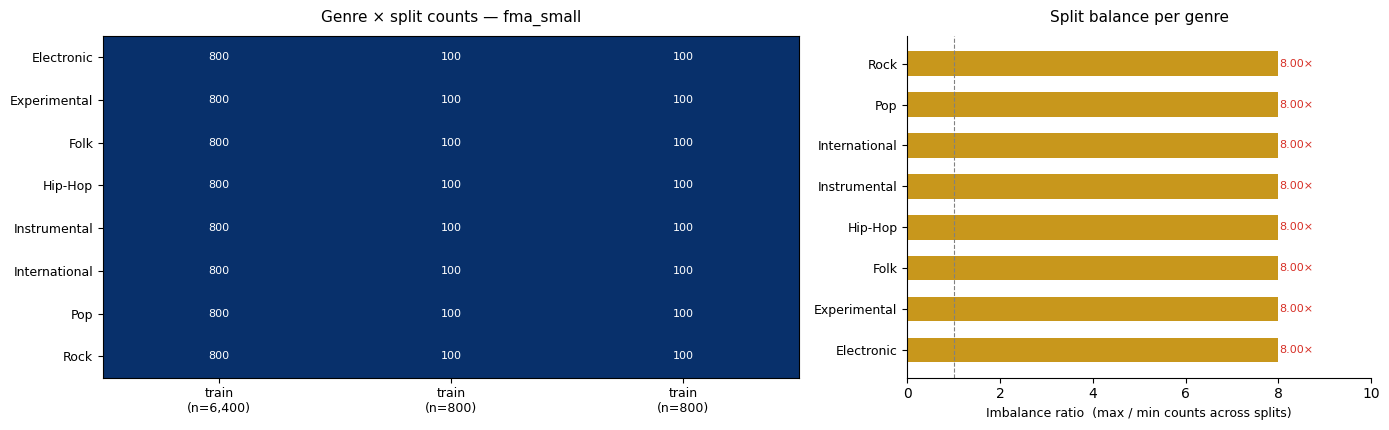

Most imbalanced genre across splits : Electronic  (ratio = 8.00×)
→ Significant imbalance detected — consider class-weighted loss or reporting Macro-F1 as the primary metric.

⏱  Genre distribution plot : 0.98s


In [ ]:

_t0 = _time_module.perf_counter()

# ── Genre distribution: heatmap + imbalance ratio ─────────────────────────────
#
# Three-identical-bars is uninformative when splits are balanced (fma_small) and
# hard to compare when they are not (fma_medium).  This layout replaces it with:
#
#   Left  — annotated heatmap (genre × split, counts as colour + text).
#            Instantly shows whether any genre/split cell is sparse or missing.
#
#   Right — imbalance ratio per genre: max_count / min_count across the three
#           splits.  Ratio = 1.0 means perfectly balanced; higher values flag
#           genres that are over-represented in one split relative to another.
#           Sorted descending so the most imbalanced genres appear at the top.

splits   = ["training", "validation", "test"]
dfs      = [train_df, val_df, test_df]
labels   = [f"train\n(n={len(d):,})" for d in dfs]

# Build (n_genres × 3) count matrix
genres_sorted = sorted(all_genres)
counts_matrix = np.array(
    [[df["genre_top"].value_counts().get(g, 0) for df in dfs] for g in genres_sorted],
    dtype=float,
)

# Normalise each split column to [0, 1] for colouring (so fma_small doesn't
# wash out to a flat colour when all values are equal)
col_max = counts_matrix.max(axis=0, keepdims=True)
col_max[col_max == 0] = 1
normed  = counts_matrix / col_max

# Imbalance ratio per genre
row_max  = counts_matrix.max(axis=1)
row_min  = counts_matrix.min(axis=1)
row_min[row_min == 0] = 1   # avoid division by zero for absent genres
imbalance = row_max / row_min
order_idx = np.argsort(imbalance)[::-1]   # most imbalanced first

fig, (ax_heat, ax_imb) = plt.subplots(
    1, 2,
    figsize=(14, max(4, len(genres_sorted) * 0.55)),
    gridspec_kw={"width_ratios": [3, 2]},
)

# ── Left: heatmap ─────────────────────────────────────────────────────────────
im = ax_heat.imshow(normed, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax_heat.set_xticks(range(3))
ax_heat.set_xticklabels(labels, fontsize=9)
ax_heat.set_yticks(range(len(genres_sorted)))
ax_heat.set_yticklabels(genres_sorted, fontsize=9)
ax_heat.set_title(f"Genre × split counts — fma_{SUBSET}", fontsize=11, pad=10)
for i, genre in enumerate(genres_sorted):
    for j in range(3):
        cnt = int(counts_matrix[i, j])
        text_col = "white" if normed[i, j] > 0.55 else "black"
        ax_heat.text(j, i, f"{cnt:,}", ha="center", va="center",
                     fontsize=8, color=text_col)

# ── Right: imbalance ratio ─────────────────────────────────────────────────────
y_pos = np.arange(len(genres_sorted))
ratios_sorted   = imbalance[order_idx]
genres_reordered = [genres_sorted[k] for k in order_idx]

bar_colors = ["#c8971c" if r > 1.5 else "#2583c1" for r in ratios_sorted]
ax_imb.barh(y_pos, ratios_sorted, color=bar_colors, height=0.6, edgecolor="none")
ax_imb.axvline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax_imb.set_yticks(y_pos)
ax_imb.set_yticklabels(genres_reordered, fontsize=9)
ax_imb.set_xlabel("Imbalance ratio  (max / min counts across splits)", fontsize=9)
ax_imb.set_title("Split balance per genre", fontsize=11, pad=10)
# Annotate each bar with its ratio value
for y, r in zip(y_pos, ratios_sorted):
    ax_imb.text(r + 0.02, y, f"{r:.2f}×", va="center", fontsize=8,
                color="#dc8d17" if r > 1.5 else "#159dd3")
ax_imb.set_xlim(0, ratios_sorted.max() * 1.25)
for spine in ["top", "right"]:
    ax_imb.spines[spine].set_visible(False)
ax_imb.invert_yaxis()

plt.tight_layout()
plt.show()

# ── Summary note ──────────────────────────────────────────────────────────────
worst_genre = genres_sorted[int(np.argmax(imbalance))]
worst_ratio = float(imbalance.max())
print(f"Most imbalanced genre across splits : {worst_genre}  "
      f"(ratio = {worst_ratio:.2f}×)")
if worst_ratio <= 1.05:
    print("→ All genres are near-perfectly balanced across splits.")
elif worst_ratio <= 2.0:
    print("→ Minor imbalance; using class-weighted loss is optional.")
else:
    print("→ Significant imbalance detected — consider class-weighted loss or "
          "reporting Macro-F1 as the primary metric.")

_section_times["3b. Genre plot"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Genre distribution plot : {_section_times['3b. Genre plot']:.2f}s")



## 4. MFCC Feature Extraction

Each 30-second clip is loaded at `sr=22050 Hz`, and 13 MFCC coefficients are computed with
`n_fft=512`, `hop_length=256`, yielding a `(13, 2582)` spectrogram.
Shorter clips are zero-padded; longer ones are truncated.

Results are cached as `.npy` files so subsequent runs skip extraction entirely.

### The `dequantization failed` warning

During extraction you may see messages like:

```
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
```

**What it means:** libmpg123 (the C MP3 decoder) found a frame whose Huffman-coded
packet is corrupt or malformed. It cannot reconstruct the PCM samples for that ~26 ms
window, so it **zeros those samples and continues**. The audio array returned by
`librosa.load` has the correct length and the MFCC matrix has the correct shape, but
values for the affected time windows are wrong (silence instead of real signal).

**Why it doesn't crash:** The error is non-fatal — libmpg123 recovers automatically.
No Python exception is raised, so `load_mfcc` returns a seemingly valid array.
This is why the warning is easy to overlook.

**Impact in FMA:** Roughly 1–5 % of FMA tracks have at least one corrupt frame.
Each corrupt track contributes subtly wrong features to its MFCC matrix.

**Control via `SKIP_DEGRADED` (config cell):**

| `SKIP_DEGRADED` | Behaviour |
|---|---|
| `False` (default) | Tracks with corrupt frames are **included**. Degraded count is printed separately. Use this for the faithful FMA baseline. |
| `True` | Tracks with corrupt frames are **excluded** (treated as unreadable). Use this for cleaner input in your own model variants. Requires clearing the cache (`CLEAR_CACHE = True`) to take effect. |

The warning is detected by temporarily redirecting OS file descriptor 2 to a pipe during
`librosa.load()`, then scanning the captured output for libmpg123 error strings — the only
reliable way to catch C-library stderr inside a Python process.


In [8]:
import librosa
import os
import concurrent.futures as _fut

# ─────────────────────────────────────────────────────────────────────────────
# MFCC extraction (fast path)
#   - no C-level stderr capture (much faster)
#   - cheap sanity checks to skip broken/garbage audio
#   - per-track .npy cache + per-split index parquet
# ─────────────────────────────────────────────────────────────────────────────

def _track_id_from_path(filepath: Path) -> int:
    # FMA files are usually <track_id>.mp3, so use filename stem as id.
    try:
        return int(Path(filepath).stem)
    except Exception:
        # Fallback: deterministic-ish hash of path string
        return abs(hash(str(filepath))) % (10**12)


def _load_audio_simple(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    # Decode audio with librosa (no stderr capture).
    # Optional upgrade (faster): decode/resample with ffmpeg, then compute MFCC.
    y, _sr = librosa.load(str(filepath), sr=sr, mono=mono, duration=duration)
    return y


def _sanity_check_audio(y: np.ndarray, sr: int) -> tuple[bool, str]:
    # Return (ok, reason). Reason is empty when ok.
    if y is None or len(y) == 0:
        return False, "empty_audio"
    if not np.isfinite(y).all():
        return False, "non_finite_samples"
    if len(y) < int(MIN_SECONDS * sr):
        return False, f"too_short(<{MIN_SECONDS}s)"
    if SKIP_SILENT:
        peak = float(np.max(np.abs(y)))
        st   = float(np.std(y))
        if peak < SILENCE_PEAK or st < SILENCE_STD:
            return False, "near_silent"
    return True, ""


def _mfcc_fixed_shape(y: np.ndarray) -> np.ndarray:
    # Compute MFCC and return float32 array of fixed shape (N_MFCC, N_FRAMES).
    mfcc = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    out = np.zeros(MFCC_SHAPE, dtype=np.float32)
    n = min(mfcc.shape[1], N_FRAMES)
    out[:, :n] = mfcc[:, :n].astype(np.float32, copy=False)
    return out


def _process_one_track(task: tuple) -> dict:
    # Worker: compute and cache one track.
    # task = (filepath_str, split_name, genre_top, track_id, mfcc_cache_dir)
    filepath_str, split_name, genre_top, track_id, mfcc_cache_dir = task
    filepath = Path(filepath_str)
    mfcc_path = Path(mfcc_cache_dir) / f"{track_id}.npy"

    # Fast path: already cached
    if mfcc_path.exists():
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": str(mfcc_path),
            "status": "cached",
            "reason": "",
        }

    # Decode + sanity checks + MFCC
    try:
        y = _load_audio_simple(filepath, sr=SAMPLE_RATE, mono=True, duration=30.0)
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": "",
            "status": "skipped",
            "reason": f"decode_fail:{type(exc).__name__}",
        }

    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": "",
            "status": "skipped",
            "reason": reason,
        }

    try:
        mfcc = _mfcc_fixed_shape(y)
        mfcc_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(mfcc_path, mfcc)
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": str(mfcc_path),
            "status": "ok",
            "reason": "",
        }
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": "",
            "status": "skipped",
            "reason": f"mfcc_fail:{type(exc).__name__}",
        }


def build_mfcc_index(
    split_df: pd.DataFrame,
    split_name: str,
    cache_dir: Path,
    num_workers: int,
    clear_cache: bool = False,
) -> pd.DataFrame:
    # Build (or load) a per-split MFCC index parquet.
    cache_dir.mkdir(parents=True, exist_ok=True)
    index_path = CACHE_DIR / f"mfcc_index_{split_name}_{SUBSET}.parquet"

    if clear_cache:
        # wipe per-track cache + indexes (restartable preprocessing)
        if cache_dir.exists():
            import shutil
            shutil.rmtree(cache_dir, ignore_errors=True)
        if index_path.exists():
            index_path.unlink()

    if index_path.exists():
        print(f"  [{split_name}] Loading MFCC index from cache …")
        return pd.read_parquet(index_path)

    print(f"  [{split_name}] Building MFCC cache with {num_workers} workers …")
    tasks = []
    for row in split_df.itertuples(index=False):
        fp = getattr(row, "filepath") if hasattr(row, "filepath") else row[split_df.columns.get_loc("filepath")]
        gt = getattr(row, "genre_top") if hasattr(row, "genre_top") else row[split_df.columns.get_loc("genre_top")]
        tid = _track_id_from_path(fp)
        tasks.append((str(fp), split_name, str(gt), int(tid), str(cache_dir)))

    results = []
    skipped = 0
    t0 = time.time()

    with _fut.ProcessPoolExecutor(max_workers=num_workers) as ex:
        for i, res in enumerate(ex.map(_process_one_track, tasks, chunksize=32), start=1):
            results.append(res)
            if res["status"] == "skipped":
                skipped += 1
            if i % 500 == 0 or i == len(tasks):
                elapsed = time.time() - t0
                print(f"    {i}/{len(tasks)}  skipped={skipped}  — {elapsed:.0f}s elapsed")

    index_df = pd.DataFrame(results)
    index_df.to_parquet(index_path, index=False)
    print(f"    Saved index → {index_path}")
    return index_df


In [ ]:
_t0 = _time_module.perf_counter()

print("Building/loading MFCC per-track cache + index parquets …\n")

train_index = build_mfcc_index(train_df, "training",   MFCC_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)
val_index   = build_mfcc_index(val_df,   "validation", MFCC_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)
test_index  = build_mfcc_index(test_df,  "test",       MFCC_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)

def _usable(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["status"].isin(["ok", "cached"])].reset_index(drop=True)

train_index_u = _usable(train_index)
val_index_u   = _usable(val_index)
test_index_u  = _usable(test_index)

print("\nUsable rows:")
print(f"  train: {len(train_index_u):,} / {len(train_index):,}")
print(f"  val  : {len(val_index_u):,} / {len(val_index):,}")
print(f"  test : {len(test_index_u):,} / {len(test_index):,}")

_section_times["4. MFCC extraction (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  MFCC cache+index : {_section_times['4. MFCC extraction (refactor)']:.2f}s")


Building/loading MFCC per-track cache + index parquets …

  [training] Building MFCC cache with 8 workers …


[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!


    500/6400  skipped=0  — 107s elapsed


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


    1000/6400  skipped=0  — 196s elapsed
    1500/6400  skipped=0  — 283s elapsed


...

    3500/6400  skipped=1  — 636s elapsed


/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


    4000/6400  skipped=3  — 726s elapsed
    4500/6400  skipped=3  — 811s elapsed
    5000/6400  skipped=3  — 894s elapsed


/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/.venv311/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


    5500/6400  skipped=3  — 982s elapsed
    6000/6400  skipped=4  — 1068s elapsed
    6400/6400  skipped=4  — 1109s elapsed
    Saved index → /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/mfcc_index_training_small.parquet
  [validation] Building MFCC cache with 8 workers …


In [ ]:
_t0 = _time_module.perf_counter()

# ── Visualise one example MFCC from the training set ─────────────────────────
idx_row = 0
row = train_index_u.iloc[idx_row]
mfcc = np.load(row["mfcc_path"])
genre = row["genre_top"]

fig, ax = plt.subplots(figsize=(14, 3))
img = ax.imshow(mfcc, aspect="auto", origin="lower",
                extent=[0, N_FRAMES * HOP_LENGTH / SAMPLE_RATE, 0, N_MFCC],
                cmap="magma")
ax.set_title(f"Sample MFCC — genre: {genre}  (track_id={row['track_id']})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("MFCC coefficient")
plt.colorbar(img, ax=ax, label="Coefficient value")
plt.tight_layout()
plt.show()

_section_times["4b. MFCC plot"] = _time_module.perf_counter() - _t0
print(f"⏱  MFCC sample plot : {_section_times['4b. MFCC plot']:.2f}s")


## 5. Preprocessing

1. **Add channel dimension** — Conv2D expects `(N, H, W, C)`, so reshape `(N, 13, 2582)` → `(N, 13, 2582, 1)`.
2. **Standardise** — compute per-MFCC-coefficient mean and std over the training set; apply to val and test.
   This prevents any information from val/test leaking into normalisation statistics.
3. **One-hot encode** labels for `categorical_crossentropy`.

In [ ]:
_t0 = _time_module.perf_counter()

# ── Label encoding ───────────────────────────────────────────────────────────
train_index_u["label_int"] = label_enc.transform(train_index_u["genre_top"].to_numpy())
val_index_u["label_int"]   = label_enc.transform(val_index_u["genre_top"].to_numpy())
test_index_u["label_int"]  = label_enc.transform(test_index_u["genre_top"].to_numpy())

# ── Compute per-coefficient mean/std over TRAIN (streaming, no big X_train RAM) ──
def compute_train_stats(index_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    sum_c   = np.zeros((N_MFCC,), dtype=np.float64)
    sumsq_c = np.zeros((N_MFCC,), dtype=np.float64)
    count = 0

    for i, p in enumerate(index_df["mfcc_path"]):
        x = np.load(p)  # (13, 2582)
        sum_c   += x.sum(axis=1)
        sumsq_c += (x * x).sum(axis=1)
        count   += x.shape[1]
        if (i + 1) % 2000 == 0:
            print(f"  stats pass: {i+1}/{len(index_df)}")

    mean = sum_c / max(1, count)
    var  = (sumsq_c / max(1, count)) - mean**2
    std  = np.sqrt(np.maximum(var, 1e-12))

    mu  = mean.reshape((1, N_MFCC, 1, 1)).astype(np.float32)
    sig = std.reshape((1, N_MFCC, 1, 1)).astype(np.float32)
    return mu, sig

print("Computing training mean/std (streaming) …")
mu, std = compute_train_stats(train_index_u)
print(f"mu shape={mu.shape}, std shape={std.shape}")

# ── tf.data input pipeline ───────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
mu_tf  = tf.constant(mu, dtype=tf.float32)
std_tf = tf.constant(std, dtype=tf.float32)

def _np_load_mfcc(path_bytes):
    path = path_bytes.decode("utf-8")
    x = np.load(path).astype(np.float32, copy=False)  # (13, 2582)
    x = x[..., np.newaxis]                            # (13, 2582, 1)
    return x

def make_dataset(index_df: pd.DataFrame, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    paths  = index_df["mfcc_path"].to_numpy(dtype=str)
    labels = index_df["label_int"].to_numpy(dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10_000), reshuffle_each_iteration=True)

    def _load_and_norm(path, y):
        x = tf.numpy_function(_np_load_mfcc, [path], Tout=tf.float32)
        x.set_shape((*MFCC_SHAPE, 1))
        x = (x - mu_tf[0]) / std_tf[0]
        y_oh = tf.one_hot(y, N_CLASSES)
        return x, y_oh

    ds = ds.map(_load_and_norm, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_index_u, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_index_u,   BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(test_index_u,  BATCH_SIZE, shuffle=False)

print("Datasets ready:")
print(f"  train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"  val   batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"  test  batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

_section_times["5. Preprocessing (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Preprocessing : {_section_times['5. Preprocessing (refactor)']:.2f}s")


## 6. Build the CNN Model

Direct Keras translation of the original FMA architecture.
No batch normalisation, no dropout — kept faithful to the original paper.

In [ ]:
_t0 = _time_module.perf_counter()

def build_model(n_classes: int) -> keras.Model:
    """2D CNN on MFCC spectrograms — faithful to FMA baselines.ipynb §3.1.

    Conv2D(3,  (13,10), stride (1,4)) → (1,  644,  3)
    Conv2D(15, (1, 10), stride (1,4)) → (1,  159, 15)
    Conv2D(65, (1, 10), stride (1,4)) → (1,   38, 65)
    Flatten                           → (2470,)
    Dense(n_classes, softmax)
    """
    inputs = keras.Input(shape=(*MFCC_SHAPE, 1), name="mfcc")   # (13, 2582, 1)

    x = layers.Conv2D(3,  (13, 10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv1")(inputs)
    x = layers.Conv2D(15, (1,  10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv2")(x)
    x = layers.Conv2D(65, (1,  10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv3")(x)
    x = layers.Flatten(name="flatten")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="fc_out")(x)

    return keras.Model(inputs, outputs, name="mfcc_2dcnn_baseline")


with tf.device(RUNTIME_DEVICE):
    model = build_model(N_CLASSES)

model.summary()

_section_times["6. Build model"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Build model : {_section_times['6. Build model']:.2f}s")

## 7. Compile & Train

Optimizer, loss, and epoch count are identical to the original FMA baseline.
`shuffle=True` is set to randomise the order within each epoch.

In [ ]:
_t0 = _time_module.perf_counter()

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

print(f"Training on {RUNTIME_DEVICE}  |  epochs={EPOCHS}, batch_size={BATCH_SIZE}\n")

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
    )

# ── Save model ───────────────────────────────────────────────────────────────
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "baseline_mfcc_cnn.keras"
model.save(str(model_path))
print(f"\nModel saved → {model_path}")

_section_times["7. Compile & train (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Compile & train : {_section_times['7. Compile & train (refactor)']:.1f}s  "
      f"({_section_times['7. Compile & train (refactor)']/EPOCHS:.1f}s per epoch)")


## 8. Training History

Plot accuracy and loss curves over epochs for both train and validation sets.
A growing gap between the two curves signals overfitting.

In [ ]:
_t0 = _time_module.perf_counter()

hist = history.history
epochs_range = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
ax_acc.plot(epochs_range, hist["accuracy"],     label="Train",      linewidth=2)
ax_acc.plot(epochs_range, hist["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_acc.spines[spine].set_visible(False)

# Loss
ax_loss.plot(epochs_range, hist["loss"],     label="Train",      linewidth=2)
ax_loss.plot(epochs_range, hist["val_loss"], label="Validation", linewidth=2, linestyle="--")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Categorical cross-entropy")
ax_loss.legend()
ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_loss.spines[spine].set_visible(False)

fig.suptitle("Training history — MFCC 2D CNN baseline", fontsize=13)
plt.tight_layout()
plt.show()

final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]
print(f"Final train accuracy : {final_train_acc:.4f}  ({final_train_acc:.2%})")
print(f"Final val   accuracy : {final_val_acc:.4f}  ({final_val_acc:.2%})")

_section_times["8. Training history plot"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Training history plot : {_section_times['8. Training history plot']:.2f}s")

## 9. Evaluate the Model

Report accuracy, Macro-F1, and per-genre F1 on all three splits.
Results are also saved to `MelCNN-MGR/results/baseline_mfcc_cnn_results.txt`.

In [ ]:
_t0 = _time_module.perf_counter()

def eval_dataset(model, ds: tf.data.Dataset, genre_classes, split_label: str):
    # Return (formatted_block, y_true_int, y_pred_int) for a dataset.
    y_true, y_pred = [], []
    for xb, yb in ds:
        pred = model.predict(xb, verbose=0)
        y_pred.append(np.argmax(pred, axis=1))
        y_true.append(np.argmax(yb.numpy(), axis=1))
    y_true = np.concatenate(y_true) if y_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(y_pred) if y_pred else np.array([], dtype=np.int64)

    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    report   = classification_report(y_true, y_pred,
                                     target_names=genre_classes, zero_division=0)
    block = (
        f"\n{'='*60}\n {split_label}\n{'='*60}\n"
        f"  Accuracy : {acc:.4f}  ({acc:.2%})\n"
        f"  Macro-F1 : {macro_f1:.4f}\n\n"
        f"Per-genre classification report:\n{report}"
    )
    print(block)
    return block, y_true, y_pred


results_lines: list[str] = [
    "FMA Baseline Reproducer — MFCC → 2D CNN (refactored pipeline)\n",
    f"Epochs={EPOCHS}, batch_size={BATCH_SIZE}\n",
    f"Training samples  : {len(train_index_u):,}\n"
    f"Validation samples: {len(val_index_u):,}\n"
    f"Test samples      : {len(test_index_u):,}\n",
]

with tf.device(RUNTIME_DEVICE):
    train_block, y_train_true, y_train_pred = eval_dataset(model, train_ds, GENRE_CLASSES, "TRAIN SET")
    val_block,   y_val_true,   y_val_pred   = eval_dataset(model, val_ds,   GENRE_CLASSES, "VALIDATION SET")
    test_block,  y_test_true,  y_test_pred  = eval_dataset(model, test_ds,  GENRE_CLASSES, "TEST SET")

results_lines += [train_block, val_block, test_block]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results_path = RESULTS_DIR / f"mfcc_cnn_results_{SUBSET}.txt"
results_path.write_text("\n".join(results_lines))
print(f"\nResults saved → {results_path}")

_section_times["9. Evaluation (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Evaluation : {_section_times['9. Evaluation (refactor)']:.2f}s")


In [ ]:
_t0 = _time_module.perf_counter()

# ── Confusion matrix (test set) ───────────────────────────────────────────────
cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRE_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Confusion matrix — test set", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

_section_times["9b. Confusion matrix (refactor)"] = _time_module.perf_counter() - _t0
print(f"⏱  Confusion matrix : {_section_times['9b. Confusion matrix (refactor)']:.2f}s")


## 10. Predict on a New Audio Sample

Set `INFER_PATH` to any MP3 file to predict its genre with the trained model.
By default this cell re-uses a random sample from the test set so it runs without
additional files.

In [ ]:
_t0 = _time_module.perf_counter()

INFER_PATH = None   # e.g. Path("/path/to/my_track.mp3")

if INFER_PATH is None:
    rng_idx    = np.random.randint(len(test_df))
    INFER_PATH = Path(test_df.iloc[rng_idx]["filepath"])
    true_genre = test_df.iloc[rng_idx]["genre_top"]
    print(f"Using test sample: {INFER_PATH.name}  (true genre: {true_genre})")
else:
    true_genre = "?"

try:
    y = _load_audio_simple(Path(INFER_PATH), sr=SAMPLE_RATE, mono=True, duration=30.0)
    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        raise ValueError(f"sanity_check_failed:{reason}")
    mfcc = _mfcc_fixed_shape(y)
except Exception as exc:
    print(f"Could not load/extract MFCC: {exc}")
    mfcc = None

if mfcc is not None:
    x_infer = ((mfcc[np.newaxis, ..., np.newaxis] - mu) / std).astype(np.float32)

    probs      = model.predict(x_infer, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_genre = GENRE_CLASSES[pred_idx]
    confidence = float(probs[pred_idx])

    print(f"\nPredicted genre : {pred_genre}  (confidence: {confidence:.2%})")
    print(f"True genre      : {true_genre}")

    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["steelblue" if g != pred_genre else "tomato" for g in GENRE_CLASSES]
    ax.barh(GENRE_CLASSES, probs, color=colors)
    ax.set_xlabel("Probability")
    ax.set_title(f"Genre probabilities — {INFER_PATH.name}")
    ax.axvline(1 / N_CLASSES, color="grey", linestyle="--", linewidth=0.8,
               label=f"Chance ({1/N_CLASSES:.2%})")
    ax.legend(fontsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

_section_times["10. Inference (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Inference : {_section_times['10. Inference (refactor)']:.2f}s")


---

## Runtime Summary

In [ ]:
_total = _time_module.perf_counter() - _T0

SEP = "=" * 52
print(SEP)
print("  Runtime summary")
print(SEP)
for section, elapsed in _section_times.items():
    bar_len  = max(1, int(elapsed / _total * 30))
    bar      = "█" * bar_len
    pct      = elapsed / _total * 100
    mins, secs = divmod(elapsed, 60)
    time_str = f"{int(mins)}m {secs:04.1f}s" if mins else f"{elapsed:6.1f}s"
    print(f"  {section:<28}  {time_str:>9}  {pct:5.1f}%  {bar}")

print(SEP)
mins_total, secs_total = divmod(_total, 60)
total_str = f"{int(mins_total)}m {secs_total:04.1f}s" if mins_total else f"{_total:.1f}s"
print(f"  {'TOTAL':<28}  {total_str:>9}")
print(SEP)

---

# Performance Engineering: From MFCC Pipeline v2 → v3

## 1. Background

Version 2 of the MFCC pipeline (MelCNN-MGR/model_training/baseline_mfcc_cnn_v2.ipynb) implemented a functional baseline for music genre classification using the **FMA dataset**. The system successfully:

* Loads MP3 audio clips
* Extracts **Mel-frequency cepstral coefficients (MFCC)**
* Builds train / validation / test datasets
* Trains a CNN classifier

While the system works correctly, experiments revealed that **feature extraction became the dominant performance bottleneck**, especially when scaling from small subsets to larger datasets such as **FMA-medium**.

In practice, **MFCC extraction time greatly exceeded model training time**, making experimentation slow and inefficient.

Therefore, **Story 2 focuses on performance optimization of the data pipeline**, transforming Version 2 into Version 3.

---

# 2. Version 2 Pipeline Architecture

Version 2 processes MFCC features in the following way.

### Version 2 Architecture

```mermaid
flowchart TD

A[MP3 File] --> B[librosa.load]
B --> C[Capture stderr logs from decoder]
C --> D[MFCC computation]
D --> E[Append MFCC to Python list]
E --> F[np.stack all features]
F --> G[Large in-memory array]
G --> H[Save cache file: X_train.npy]
H --> I[CNN training]
```

### Processing Workflow

For each dataset split (train / validation / test):

1. Iterate through dataset metadata
2. Load MP3 audio using `librosa.load`
3. Capture **decoder stderr output** to detect degraded MP3 frames
4. Compute MFCC features
5. Append features to a Python list
6. Stack all MFCC arrays into a large tensor
7. Save cached feature arrays

While conceptually simple, this design introduces several **performance and scalability issues**.

---

# 3. Performance Issues Identified in Version 2

## 3.1 Sequential Processing

MFCC extraction runs **file-by-file in a single thread**.

```
for each audio file:
    decode mp3
    compute mfcc
```

Modern CPUs provide multiple cores, but Version 2 only uses one.

**Result**

* CPU underutilization
* Slow feature extraction

---

## 3.2 Expensive stderr Capture

Version 2 captures **C-level decoder stderr logs** for every file to detect warnings such as:

```
dequantization failed
```

This requires:

* redirecting file descriptors
* capturing stderr pipes
* scanning log messages

Even though most files are clean, the capture occurs **for every audio file**.

**Result**

* additional OS-level overhead
* unnecessary processing

---

## 3.3 Large In-Memory Feature Assembly

MFCC arrays are first accumulated in Python lists.

```
Xs.append(mfcc)
...
X = np.stack(Xs)
```

When the dataset becomes large:

* memory usage spikes
* `np.stack()` becomes expensive
* system may experience memory pressure

---

## 3.4 Repeated MP3 Decoding

Every experiment re-runs the entire pipeline:

```
MP3 decode
MFCC compute
repeat
```

However, the audio content **does not change between experiments**.

**Result**

* repeated expensive decoding
* slow iteration cycles

---

# 4. Design Goals for Version 3

Version 3 aims to significantly improve performance while keeping the system simple and notebook-friendly.

The key goals are:

1. Remove unnecessary overhead
2. Utilize multi-core CPUs
3. Avoid large in-memory feature arrays
4. Cache feature extraction results
5. Enable faster experimentation

---

# 5. Version 3 Architecture

Version 3 introduces a redesigned feature pipeline.

### Version 3 Architecture

```mermaid
flowchart TD

A[MP3 File] --> B[Parallel MFCC extraction workers]
B --> C[Load audio with librosa]
C --> D[Cheap sanity checks]
D --> E[MFCC computation]
E --> F[Save per-track MFCC cache]
F --> G[cache/mfcc/<track_id>.npy]

G --> H[MFCC index parquet manifest]

H --> I[tf.data streaming loader]
I --> J[Batching and normalization]
J --> K[CNN training]
```

This architecture separates **feature extraction** from **model training**.

---

# 6. Key Improvements in Version 3

## 6.1 Remove stderr Capture

The feature extraction hot path now loads audio directly:

```python
librosa.load(filepath)
```

Unreadable files are still handled safely using:

```python
try:
    load audio
except:
    skip file
```

This eliminates expensive stderr capture operations while preserving robustness.

---

## 6.2 Add Cheap Sanity Checks

Instead of analyzing decoder logs, Version 3 performs lightweight validation checks on the waveform.

Examples include:

* detecting NaN or infinite values
* verifying minimum audio duration
* optionally skipping near-silent signals

Example:

```python
if not np.isfinite(y).all():
    skip
```

These checks are extremely fast and sufficient for filtering problematic audio.

---

## 6.3 Parallel MFCC Extraction

Version 3 introduces **multiprocessing** using:

```
ProcessPoolExecutor
```

Each worker independently processes an audio file:

```
load audio
compute MFCC
save MFCC
```

**Benefits**

* fully utilizes multi-core CPUs
* dramatically reduces preprocessing time

---

## 6.4 Per-Track MFCC Cache

Instead of constructing a single large array, MFCC features are stored per track.

```
cache/
  mfcc/
    train/
      000123.npy
      000124.npy
    validation/
    test/
```

Each file stores:

```
shape: (N_MFCC, N_FRAMES)
dtype: float32
```

**Advantages**

* avoids large memory allocations
* enables restartable extraction
* eliminates repeated decoding across experiments

---

## 6.5 Metadata Index (Parquet)

A manifest file is generated alongside the MFCC cache.

Example:

```
cache/mfcc_index_train.parquet
```

Columns include:

| column    | description          |
| --------- | -------------------- |
| track_id  | FMA track identifier |
| filepath  | original MP3 path    |
| mfcc_path | cached MFCC file     |
| split     | dataset split        |
| label     | genre label          |
| status    | ok / skipped         |
| reason    | error reason         |

This provides a clean interface between **data preprocessing and model training**.

---

## 6.6 Streaming Training Data Loader

Training now uses **TensorFlow's tf.data pipeline** instead of loading entire datasets into memory.

Data flow:

```
mfcc_path
    ↓
np.load()
    ↓
normalization
    ↓
batch
    ↓
prefetch
```

**Benefits**

* small memory footprint
* efficient CPU/GPU overlap
* scalable to larger datasets

---

# 7. Version 2 vs Version 3 Comparison

| Feature               | Version 2         | Version 3       |
| --------------------- | ----------------- | --------------- |
| MFCC extraction       | single-thread     | parallel        |
| stderr handling       | captured per file | removed         |
| feature storage       | large arrays      | per-track cache |
| memory usage          | high              | low             |
| restart capability    | none              | resumable       |
| experiment speed      | slow              | fast            |
| training data loading | full array        | streaming       |

---

# 8. Performance Insight

A key insight from this optimization is that **model training is often not the bottleneck**.

Instead, the slow stage is frequently **data preparation and feature extraction**.

Version 3 applies a common ML engineering pattern:

```
Expensive preprocessing
        ↓
Feature cache
        ↓
Fast experimentation
```

Once features are cached, experiments can iterate rapidly without touching the raw dataset again.

---

# 9. Conceptual Lesson

Version 3 demonstrates a core machine learning engineering principle:

> Separate expensive preprocessing from model experimentation.

This approach improves:

* development velocity
* reproducibility
* system scalability

---

# 10. Summary

Version 2 provided a correct baseline MFCC pipeline but suffered from performance limitations due to:

* sequential processing
* heavy stderr capture
* large in-memory feature arrays
* repeated MP3 decoding

Version 3 introduces a redesigned pipeline with:

* multiprocessing extraction
* lightweight audio validation
* per-track MFCC caching
* streaming training data loading

These improvements transform the system into a **scalable and efficient feature extraction pipeline suitable for larger datasets and rapid experimentation**.

---

If you'd like, I can also add **one more diagram** that often helps readers:

**Dataset lifecycle diagram**

```
Raw audio
   ↓
Feature extraction (one-time)
   ↓
MFCC cache
   ↓
Fast ML experiments
   ↓
Model improvements
```

It makes the engineering philosophy of Version 3 extremely clear.
